In [1]:
#Import required library for performing Model creation,data preprocessing, data cleaning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
# Load the Customer churn prediction dataset using the pandas library
data = pd.read_csv("/content/customer_churn_dataset-testing-master.csv")
data

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1


In [3]:
#after performing any step we first check the whole data using info from which we knew data type, null value,column names.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [4]:
#we must check that the null value is available in my data or not
data.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [5]:
#here we are removing unnecessary columns like customerid
data.drop('CustomerID',axis=1,inplace=True)

In [6]:
# we must convert the categorical data into the numeric
le = LabelEncoder()
data["Gender"] = le.fit_transform(data["Gender"])
data["Subscription Type"] = le.fit_transform(data["Subscription Type"])
data["Contract Length"] = le.fit_transform(data["Contract Length"])

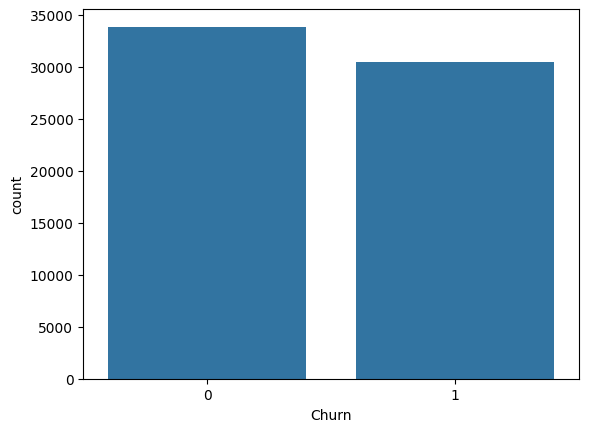

In [7]:
# Churn distribution
sns.countplot(x='Churn', data=data)
plt.show()


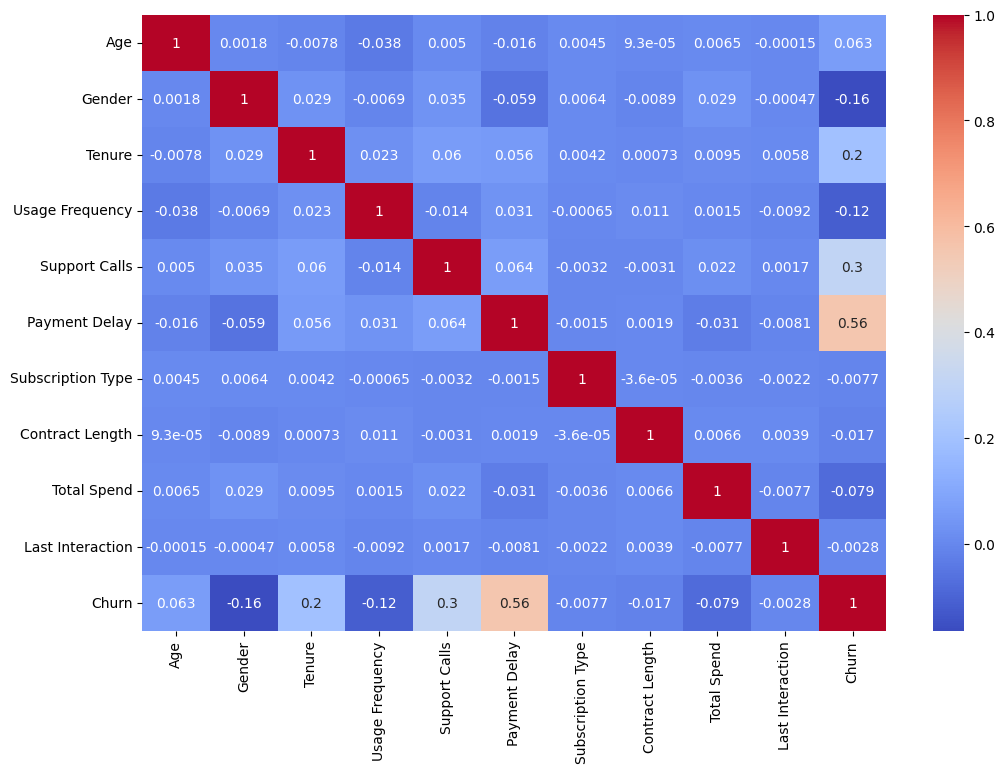

In [8]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [9]:
#here we define dependent(y) and independent(x) faeture form the data
x = data.drop('Churn',axis=1)
y = data['Churn']

In [10]:
#now here we are using train_test_split model
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 42)

In [16]:
#Here i have created a Model using logisticRegression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
print(lr.fit(x_train, y_train))
print(lr.score(x_train,y_train))
print(lr.score(x_test,y_test))


LogisticRegression(max_iter=1000)
0.8240548360162333
0.8306019417475728


In [30]:
#now i have used KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
print(knn.fit(x_train, y_train))
print(knn.score(x_train,y_train))
print(knn.score(x_test,y_test))

KNeighborsClassifier()
0.8758616672168391
0.8158446601941748


In [26]:
#now i have used random forest model
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
print(rfc.fit(x_train, y_train))
print(rfc.score(x_train,y_train))
print(rfc.score(x_test,y_test))

RandomForestClassifier()
1.0
0.9995339805825243


In [27]:
#we have select the final model as a RandomForestClassifier
# After that used metric to scale our model performance
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

y_pred = rfc.predict(x_test)

print("accuracy_score:\n ",accuracy_score(y_test, y_pred))
print("\nconfusion_matrix:\n",confusion_matrix(y_test, y_pred))
print("\nclassification_report:\n",classification_report(y_test, y_pred))

accuracy_score:
  0.9995339805825243

confusion_matrix:
 [[6791    2]
 [   4 6078]]

classification_report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6793
           1       1.00      1.00      1.00      6082

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875

